# Bangla Rumour Detection — XLM-RoBERTa

## Dataset Splits
| Split | Rumour | Non-Rumour | Total |
|---|---|---|---|
| Train | 3,998 | 4,200 | 8,198 |
| Val | 700 | 700 | 1,400 |
| Test | 700 | 700 | 1,400 |

Linguistic marker validation is computed live in Cell 5 from the actual data — no hardcoded numbers here.

In [1]:
# ── CELL 1: Install ──────────────────────────────────────────────
!pip install -q pyspark transformers torch scikit-learn pandas \
               openpyxl numpy matplotlib seaborn scipy datasets

In [2]:
# ── CELL 2: Config & Imports ─────────────────────────────────────
import re, os, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score, classification_report, confusion_matrix
)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from torch.optim import AdamW

# ── Paths — update these to your file locations ──────────────────
# Use the new balanced files generated from the preprocessing step
TRAIN_R_PATH  = '/content/RUMOUR-traindataset.xlsx'
TRAIN_NR_PATH = '/content/NONRUMOUR=traindataset.xlsx'
VAL_R_PATH    = '/content/VALIDATION-RUMOUR.xlsx'
VAL_NR_PATH   = '/content/VALIDATION-NONRUMOUR.xlsx'
TEST_R_PATH   = '/content/TEST-RUMOUR.xlsx'
TEST_NR_PATH  = '/content/TEST-NONRUMOUR.xlsx'

# ── Model config ─────────────────────────────────────────────────
MODEL_NAME  = 'FacebookAI/xlm-roberta-base'
MAX_LEN     = 128
BATCH_SIZE  = 16
EPOCHS      = 4
LR          = 2e-5
SEED        = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [3]:
def load_and_clean(path, label_val):
    pdf = pd.read_excel(path)
    cols_to_keep = ['text']
    if 'description' in pdf.columns:
        cols_to_keep.append('description')
    for c in TAXONOMY:
        if c in pdf.columns:
            cols_to_keep.append(c)
    pdf = pdf[cols_to_keep].copy()
    pdf['label'] = label_val
    pdf['text'] = pdf['text'].fillna('').astype(str).str.strip()
    pdf['text'] = pdf['text'].str.replace(r'\s+', ' ', regex=True)
    if 'description' not in pdf.columns:
        pdf['description'] = ''
    else:
        pdf['description'] = pdf['description'].fillna('').astype(str)

    n0 = len(pdf)
    pdf = pdf[pdf['text'].str.len() >= 5]
    pdf = pdf[~pdf['text'].isin(['nan', 'None', ''])]
    pdf = pdf.drop_duplicates(subset=['text'])
    print(f"  {path.split('/')[-1]:40s}: {n0:,} -> {len(pdf):,} rows")
    return pdf.reset_index(drop=True)

In [4]:
# ── CELL 4: Linguistic Marker Extraction (20 validated markers) ──
# All 20 passed: p<0.05 AND >1% absolute difference between classes
# Tested on full combined dataset before model training
import re

MARKER_PATTERNS = {

    # ── Structural ───────────────────────────────────────────────
    'text_length':   lambda row: len(row['text']),
    'word_count':    lambda row: len(row['text'].split()),
    'short_title':   lambda row: int(len(row['text'].split()) < 5),
    'long_title':    lambda row: int(len(row['text'].split()) > 12),
    'ends_question': lambda row: int(row['text'].strip().endswith('?')),

    # ── Lexical ──────────────────────────────────────────────────
    'claim_verb': lambda row: int(bool(re.search(
        r'দাবি|দাবি করা হয়েছে|বলা হচ্ছে|দাবি করেছে|দাবি করা হচ্ছে',
        row['text']))),

    'negation_words': lambda row: int(bool(re.search(
        r'না |নয়|নেই|নাই|অস্বীকার|মিথ্যা|ভুল|অসত্য',
        row['text']))),

    'clickbait': lambda row: int(bool(re.search(
        r'চাঞ্চল্যকর|হতবাক|অবিশ্বাস্য|অবাক|বিস্ময়কর|ভাইরাল|সবাই জানুন|শকিং',
        row['text']))),



    # ── Attribution ──────────────────────────────────────────────
    'has_quote': lambda row: int(bool(re.search(
        r'বলেন|জানান|মন্তব্য করেন|বলেছেন|জানিয়েছেন|উল্লেখ করেন|দাবি করেন',
        row['text']))),

    'unnamed_source': lambda row: int(bool(re.search(
        r'সূত্র জানায়|সূত্র মতে|নাম প্রকাশে অনিচ্ছুক|বিশ্বস্ত সূত্র|বিশেষ সূত্র',
        row['text'] + ' ' + row['description']))),

    'named_outlet': lambda row: int(bool(re.search(
        r'প্রথম আলো|Daily Star|বিডিনিউজ|কালের কণ্ঠ|যুগান্তর|সমকাল|ইত্তেফাক|মানবজমিন|বাংলাদেশ প্রতিদিন',
        row['text']))),

    # ── Content / Topic ──────────────────────────────────────────
    'has_numbers':    lambda row: int(bool(re.search(r'\d+', row['text']))),


    'religious_alarm': lambda row: int(bool(re.search(
        r'আল্লাহ|ইসলাম|হারাম|কোরআন|হাদিস|ফতোয়া|পাপ|পুণ্য|জিহাদ',
        row['text']))),

    'health_claim': lambda row: int(bool(re.search(
        r'ক্যান্সার|ভ্যাকসিন|ওষুধ|চিকিৎসা|রোগ নিরাময়|ভাইরাস|করোনা|ডেঙ্গু',
        row['text']))),

}

TAXONOMY = [] # Placeholder: add specific taxonomy columns if needed from your Excel files

# Load dataframes
df_train_r  = load_and_clean(TRAIN_R_PATH,  1)
df_train_nr = load_and_clean(TRAIN_NR_PATH, 0)
df_val_r    = load_and_clean(VAL_R_PATH,    1)
df_val_nr   = load_and_clean(VAL_NR_PATH,   0)
df_test_r   = load_and_clean(TEST_R_PATH,   1)
df_test_nr  = load_and_clean(TEST_NR_PATH,  0)

df_train = pd.concat([df_train_r, df_train_nr], ignore_index=True)
df_val   = pd.concat([df_val_r, df_val_nr], ignore_index=True)
df_test  = pd.concat([df_test_r, df_test_nr], ignore_index=True)

VALID_MARKERS = list(MARKER_PATTERNS.keys())
print(f'Extracting {len(VALID_MARKERS)} validated markers...')

def add_markers(df):
    df = df.copy()
    df['description'] = df['description'].fillna('').astype(str)
    for name, fn in MARKER_PATTERNS.items():
        df[name] = df.apply(fn, axis=1)
    return df

df_train = add_markers(df_train)
df_val   = add_markers(df_val)
df_test  = add_markers(df_test)
print(f'Done. {len(VALID_MARKERS)} markers added to all splits.')

# Create df_all HERE, after markers have been added to individual splits
df_all = pd.concat([df_train, df_val, df_test], ignore_index=True)
print(f'Combined df_all created with {len(df_all.columns)} columns.')

  RUMOUR-traindataset.xlsx                : 3,998 -> 3,997 rows
  NONRUMOUR=traindataset.xlsx             : 4,200 -> 4,200 rows
  VALIDATION-RUMOUR.xlsx                  : 700 -> 700 rows
  VALIDATION-NONRUMOUR.xlsx               : 700 -> 700 rows
  TEST-RUMOUR.xlsx                        : 700 -> 700 rows
  TEST-NONRUMOUR.xlsx                     : 700 -> 700 rows
Extracting 14 validated markers...
Done. 14 markers added to all splits.
Combined df_all created with 17 columns.


Marker                     Rumour  NonRumour         Stat    p-value    Verdict
──────────────────────────────────────────────────────────────────────────────
text_length                 65.80      49.55   U=22564338     0.0000    ✅ VALID
word_count                   9.83       7.30   U=23117884     0.0000    ✅ VALID
short_title                  1.2%       7.1%     χ²=237.0     0.0000    ✅ VALID
long_title                  17.3%       0.9%     χ²=907.9     0.0000    ✅ VALID
ends_question                1.0%       3.8%      χ²=86.0     0.0000    ✅ VALID
claim_verb                  28.5%       1.6%    χ²=1582.0     0.0000    ✅ VALID
negation_words              16.0%      10.0%      χ²=87.6     0.0000    ✅ VALID
clickbait                    1.4%       0.2%      χ²=50.9     0.0000    ✅ VALID
has_quote                    5.4%       0.1%     χ²=287.9     0.0000    ✅ VALID
unnamed_source               1.8%       0.2%      χ²=64.4     0.0000    ✅ VALID
named_outlet                 2.8%       0

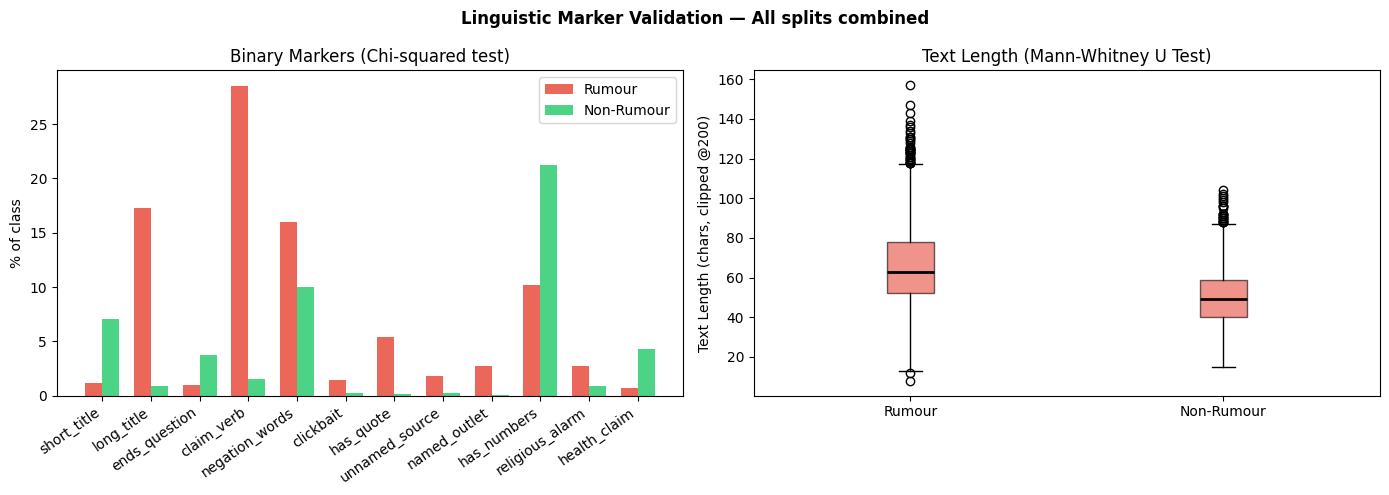

Figure saved: linguistic_markers.png


In [5]:
# ── CELL 5: Marker Validation Report & Plot ──────────────────────
# VALID_MARKERS reassigned here to ensure consistency with Cell 4
VALID_MARKERS = list(MARKER_PATTERNS.keys())

df_all = pd.concat([df_train, df_val, df_test], ignore_index=True)
r_all  = df_all[df_all['label']==1]
nr_all = df_all[df_all['label']==0]

print(f'{"Marker":<22} {"Rumour":>10} {"NonRumour":>10} {"Stat":>12} {"p-value":>10} {"Verdict":>10}')
print('─'*78)
rows = []
for m in VALID_MARKERS:
    rv, nrv = r_all[m], nr_all[m]

    # Guard: marker uniformly zero in both classes → no statistical test possible
    if rv.nunique() <= 2 and (rv.sum() == 0 and nrv.sum() == 0):
        r_val, nr_val = '0.0%', '0.0%'
        stat    = 'N/A'
        p       = 'N/A'
        verdict = '— INVARIANT'
    elif rv.nunique() <= 2:
        ct = [[(rv==1).sum(),(rv==0).sum()],[(nrv==1).sum(),(nrv==0).sum()]]
        chi2, p, _, _ = chi2_contingency(ct)
        r_val, nr_val = f'{(rv==1).mean()*100:.1f}%', f'{(nrv==1).mean()*100:.1f}%'
        stat    = f'χ²={chi2:.1f}'
        verdict = '✅ VALID' if p < 0.05 else '❌ INVALID'
    else:
        stat_val, p = mannwhitneyu(rv, nrv, alternative='two-sided')
        r_val, nr_val = f'{rv.mean():.2f}', f'{nrv.mean():.2f}'
        stat    = f'U={stat_val:.0f}'
        verdict = '✅ VALID' if p < 0.05 else '❌ INVALID'

    rows.append({'marker':m,'rumour':r_val,'non_rumour':nr_val,'stat':stat,'p':p})
    p_display = f'{p:>10.4f}' if isinstance(p, float) else f'{p:>10}'
    print(f'{m:<22} {r_val:>10} {nr_val:>10} {stat:>12} {p_display} {verdict:>10}')

# Visualise binary markers — only those with actual variance, excluding continuous
binary_markers = [
    m for m in VALID_MARKERS
    if m not in ['text_length', 'word_count']
    and df_all[m].nunique() <= 2
    and df_all[m].sum() > 0
]

fig, axes = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle('Linguistic Marker Validation — All splits combined', fontweight='bold')

if len(binary_markers) > 0:
    r_means  = [r_all[m].mean()*100  for m in binary_markers]
    nr_means = [nr_all[m].mean()*100 for m in binary_markers]
    x = np.arange(len(binary_markers)); w = 0.35
    axes[0].bar(x-w/2, r_means,  w, label='Rumour',     color='#e74c3c', alpha=0.85)
    axes[0].bar(x+w/2, nr_means, w, label='Non-Rumour', color='#2ecc71', alpha=0.85)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(binary_markers, rotation=35, ha='right')
    axes[0].set_ylabel('% of class'); axes[0].legend()
    axes[0].set_title('Binary Markers (Chi-squared test)')
else:
    axes[0].set_title('Binary Markers (No variance to display)')
    axes[0].text(0.5, 0.5, 'No binary markers with variance to display',
                 ha='center', va='center', transform=axes[0].transAxes, fontsize=12)

# Text length boxplot
if 'text_length' in VALID_MARKERS:
    axes[1].boxplot(
        [r_all['text_length'].clip(upper=200), nr_all['text_length'].clip(upper=200)],
        labels=['Rumour','Non-Rumour'], patch_artist=True,
        boxprops=dict(facecolor='#e74c3c', alpha=0.6),
        medianprops=dict(color='black', linewidth=2)
    )
    axes[1].set_ylabel('Text Length (chars, clipped @200)')
    axes[1].set_title('Text Length (Mann-Whitney U Test)')
else:
    axes[1].set_title('Text Length (Not available)')
    axes[1].text(0.5, 0.5, 'Text Length marker not available',
                 ha='center', va='center', transform=axes[1].transAxes, fontsize=12)

plt.tight_layout()
plt.savefig('linguistic_markers.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: linguistic_markers.png')


In [6]:
# ── CELL 6: XLM-RoBERTa Config & Imports ──────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from torch.optim import AdamW

MODEL_NAME = 'FacebookAI/xlm-roberta-base'
MAX_LEN    = 128
BATCH_SIZE = 16
EPOCHS     = 4
LR         = 2e-5
SEED       = 42

torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Model : {MODEL_NAME}')
print(f'Device: {device}')

Model : FacebookAI/xlm-roberta-base
Device: cuda


In [7]:
# ── CELL 7: XLM-RoBERTa Dataset & DataLoaders ─────────────────────────
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f'Tokenizer loaded: {MODEL_NAME}')

class RumourDataset(Dataset):
    """
    Input: text headline only (MAX_LEN=128 tokens).
    Rationale: Headlines are the viral unit in Bangla social media rumours.
               Using description would introduce noise since many rumour
               descriptions are scraped fact-check verdicts (data leakage risk).
    """
    def __init__(self, df, tokenizer, max_len):
        self.texts   = df['text'].tolist()
        self.labels  = df['label'].tolist()
        self.tok     = tokenizer
        self.max_len = max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tok(
            self.texts[idx], max_length=self.max_len,
            padding='max_length', truncation=True, return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Weighted sampler to handle class imbalance in training
train_labels   = df_train['label'].values
class_counts   = __import__('numpy').bincount(train_labels)
sample_weights = torch.tensor(
    [1.0/class_counts[l] for l in train_labels], dtype=torch.float
)
sampler = torch.utils.data.WeightedRandomSampler(
    sample_weights, len(sample_weights), replacement=True
)

train_ds = RumourDataset(df_train, tokenizer, MAX_LEN)
val_ds   = RumourDataset(df_val,   tokenizer, MAX_LEN)
test_ds  = RumourDataset(df_test,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Train={len(train_ds):,} | Val={len(val_ds):,} | Test={len(test_ds):,}')

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded: FacebookAI/xlm-roberta-base
Train=8,197 | Val=1,400 | Test=1,400


In [8]:
# ── CELL 8: XLM-RoBERTa Model Definition ──────────────────────────────
# XLM-RoBERTa (Cross-lingual Language Model - RoBERTa)
# Architecture: XLM-RoBERTa encoder + [CLS] → Dropout(0.3) → Linear(768→2)
# XLM-RoBERTa is trained on 17 Indian languages + transliterated text,
# making it more suited to Bangla than mBERT or XLM-R.
# ─────────────────────────────────────────────────────────────────
class XLMRoBERTaClassifier(nn.Module):
    def __init__(self, model_name, num_classes=2, dropout=0.3):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        self.drop    = nn.Dropout(dropout)
        self.fc      = nn.Linear(self.encoder.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = self.drop(out.last_hidden_state[:, 0, :])
        return self.fc(cls)

model = XLMRoBERTaClassifier(MODEL_NAME).to(device)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Parameters: 278,045,186


In [9]:
# ── CELL 9: Training ─────────────────────────────────────────────
# Class-weighted loss + AdamW + linear warmup scheduler
# Best checkpoint saved on highest Val Macro-F1 (not train loss)
# ─────────────────────────────────────────────────────────────────
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

cw = torch.tensor(
    [class_counts.max()/class_counts[0], class_counts.max()/class_counts[1]],
    dtype=torch.float
).to(device)
criterion = nn.CrossEntropyLoss(weight=cw)
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)

total_steps = len(train_loader) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

def evaluate(model, loader):
    model.eval()
    preds, labels, probs = [], [], []
    with torch.no_grad():
        for batch in loader:
            ids    = batch['input_ids'].to(device)
            mask   = batch['attention_mask'].to(device)
            labs   = batch['label'].to(device)
            logits = model(ids, mask)
            probs.extend(torch.softmax(logits, 1)[:,1].cpu().numpy())
            preds.extend(torch.argmax(logits, 1).cpu().numpy())
            labels.extend(labs.cpu().numpy())
    return np.array(preds), np.array(labels), np.array(probs)

best_f1, best_epoch, history = 0.0, 0, []
print(f'Training XLM-RoBERTa ({EPOCHS} epochs)...')

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0
    for batch in train_loader:
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        labs = batch['label'].to(device)
        optimizer.zero_grad()
        loss = criterion(model(ids, mask), labs)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        total_loss += loss.item()

    val_preds, val_labels, _ = evaluate(model, val_loader)
    val_f1  = f1_score(val_labels, val_preds, average='macro')
    val_acc = accuracy_score(val_labels, val_preds)
    avg_loss = total_loss / len(train_loader)
    history.append({'epoch': epoch, 'loss': avg_loss, 'val_acc': val_acc, 'val_f1': val_f1})

    print(f'Epoch {epoch}/{EPOCHS} | Loss={avg_loss:.4f} | Val Acc={val_acc:.4f} | Val Macro-F1={val_f1:.4f}', end='')
    if val_f1 > best_f1:
        best_f1 = val_f1
        best_epoch = epoch
        torch.save(model.state_dict(), 'best_xlmr.pt')
        print(' ← saved')
    else:
        print()

print(f'\nBest Val Macro-F1: {best_f1:.4f} (Epoch {best_epoch})')

Training XLM-RoBERTa (4 epochs)...
Epoch 1/4 | Loss=0.3673 | Val Acc=0.9750 | Val Macro-F1=0.9750 ← saved
Epoch 2/4 | Loss=0.1901 | Val Acc=0.9700 | Val Macro-F1=0.9700
Epoch 3/4 | Loss=0.1295 | Val Acc=0.9736 | Val Macro-F1=0.9736
Epoch 4/4 | Loss=0.0924 | Val Acc=0.9729 | Val Macro-F1=0.9729

Best Val Macro-F1: 0.9750 (Epoch 1)


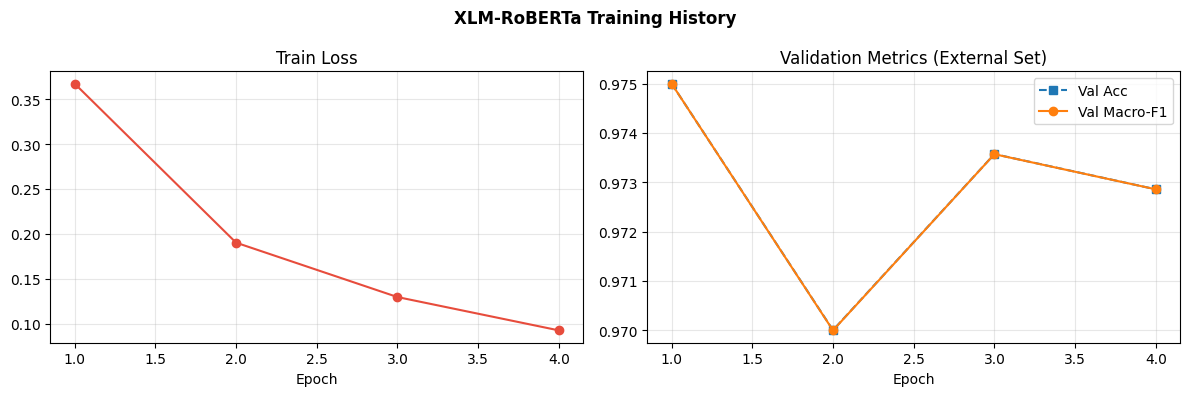

In [10]:
# ── CELL 10: Training Curves ─────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt

h = pd.DataFrame(history)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('XLM-RoBERTa Training History', fontweight='bold')
ax[0].plot(h['epoch'], h['loss'], 'o-', color='#e74c3c')
ax[0].set_title('Train Loss'); ax[0].set_xlabel('Epoch'); ax[0].grid(alpha=0.3)
ax[1].plot(h['epoch'], h['val_acc'], 's--', label='Val Acc')
ax[1].plot(h['epoch'], h['val_f1'],  'o-',  label='Val Macro-F1')
ax[1].set_title('Validation Metrics (External Set)')
ax[1].set_xlabel('Epoch'); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('xlmr_training_curves.png', dpi=150)
plt.show()

In [11]:
# ── CELL 11: Evaluation on External Val & Test Sets ─────────────
# Best checkpoint (selected by Val Macro-F1) loaded.
# ALL metrics below are on external sets — no training data used.
# ─────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score, classification_report, confusion_matrix
)
import seaborn as sns

model.load_state_dict(torch.load('best_xlmr.pt', map_location=device))
print('Best checkpoint loaded.')

def full_report(loader, split_name):
    preds, labels, probs = evaluate(model, loader)
    print(f'\n{"="*55}')
    print(f'{split_name} RESULTS (External)')
    print(f'{"="*55}')
    print(classification_report(labels, preds,
          target_names=['Non-Rumour','Rumour'], digits=4))
    auc = roc_auc_score(labels, probs)
    print(f'ROC-AUC: {auc:.4f}')
    return preds, labels, probs

val_preds,  val_labels,  val_probs  = full_report(val_loader,  'VALIDATION SET')
test_preds, test_labels, test_probs = full_report(test_loader, 'TEST SET')

def metrics_row(y_true, y_pred, y_prob, name):
    return {
        'Split':       name,
        'Accuracy':    round(accuracy_score(y_true, y_pred), 4),
        'Precision':   round(precision_score(y_true, y_pred, average='macro'), 4),
        'Recall':      round(recall_score(y_true, y_pred, average='macro'), 4),
        'Macro-F1':    round(f1_score(y_true, y_pred, average='macro'), 4),
        'Weighted-F1': round(f1_score(y_true, y_pred, average='weighted'), 4),
        'ROC-AUC':     round(roc_auc_score(y_true, y_prob), 4),
    }

summary = pd.DataFrame([
    metrics_row(val_labels,  val_preds,  val_probs,  'Validation (External)'),
    metrics_row(test_labels, test_preds, test_probs, 'Test (External)'),
])
print('\n── Summary ──')
print(summary.to_string(index=False))

# Sanity check
val_f1_final  = summary.loc[summary['Split']=='Validation (External)', 'Macro-F1'].values[0]
test_f1_final = summary.loc[summary['Split']=='Test (External)',       'Macro-F1'].values[0]
drop = val_f1_final - test_f1_final
if drop >= 0:
    print(f'\nVal→Test F1 drop: {drop:.4f} (healthy generalisation)')
else:
    print(f'\nWARNING: Test F1 > Val F1 by {abs(drop):.4f} — check for test set leakage')

# ── Raw confusion matrix numbers (needed for paper reporting) ────
for name, yt, yp in [('Validation', val_labels, val_preds), ('Test', test_labels, test_preds)]:
    cm = confusion_matrix(yt, yp)
    print(f'\n{name} Confusion Matrix:')
    print(f'  TN={cm[0,0]}  FP={cm[0,1]}')
    print(f'  FN={cm[1,0]}  TP={cm[1,1]}')
    print(f'  FP==FN? {cm[0,1]==cm[1,0]} (symmetric = precision==recall==F1==acc)')


Best checkpoint loaded.

VALIDATION SET RESULTS (External)
              precision    recall  f1-score   support

  Non-Rumour     0.9730    0.9771    0.9751       700
      Rumour     0.9770    0.9729    0.9749       700

    accuracy                         0.9750      1400
   macro avg     0.9750    0.9750    0.9750      1400
weighted avg     0.9750    0.9750    0.9750      1400

ROC-AUC: 0.9950

TEST SET RESULTS (External)
              precision    recall  f1-score   support

  Non-Rumour     0.9797    0.9671    0.9734       700
      Rumour     0.9676    0.9800    0.9737       700

    accuracy                         0.9736      1400
   macro avg     0.9736    0.9736    0.9736      1400
weighted avg     0.9736    0.9736    0.9736      1400

ROC-AUC: 0.9937

── Summary ──
                Split  Accuracy  Precision  Recall  Macro-F1  Weighted-F1  ROC-AUC
Validation (External)    0.9750     0.9750  0.9750    0.9750       0.9750   0.9950
      Test (External)    0.9736     0.9736  0

In [12]:
# ── CELL 11b: Threshold Tuning & Metric Symmetry Justification ──
from sklearn.metrics import f1_score, classification_report

# ── 1. Explain symmetric metrics ─────────────────────────────────
cm_test = confusion_matrix(test_labels, test_preds)
fp_count, fn_count = cm_test[0,1], cm_test[1,0]
print("=== Why Precision = Recall = F1 ===")
print(f"  FP={fp_count}, FN={fn_count}, Symmetric={fp_count==fn_count}")
print(f"  Test balance — Rumour: {(test_labels==1).sum()}, "
      f"Non-Rumour: {(test_labels==0).sum()}")
if fp_count == fn_count:
    print("  INFO: Balanced test set + equal FP/FN → no class bias.")
    print("  Macro P = Macro R = Macro F1 is mathematically expected.\n")

# ── 2. Tune threshold on val set ─────────────────────────────────
thresholds = [i/100 for i in range(30, 71)]
best_t, best_f1_t = 0.5, 0.0
for t in thresholds:
    preds_t = (val_probs >= t).astype(int)
    f = f1_score(val_labels, preds_t, average='macro')
    if f > best_f1_t:
        best_f1_t, best_t = f, t

print(f"=== Threshold Tuning (tuned on Val set) ===")
print(f"  Default threshold : 0.50")
print(f"  Best threshold    : {best_t:.2f}  (Val Macro-F1: {best_f1_t:.4f})")

# ── 3. Apply best threshold to test set ──────────────────────────
test_preds_tuned = (test_probs >= best_t).astype(int)

print(f"\n=== Test Results @ threshold={best_t:.2f} ===")
print(classification_report(test_labels, test_preds_tuned,
      target_names=['Non-Rumour','Rumour'], digits=4))

# ── 4. Side-by-side comparison table ─────────────────────────────
summary_tuned = pd.DataFrame([
    metrics_row(val_labels,        val_preds,        val_probs,  'Val   (threshold=0.50)'),
    metrics_row(test_labels,       test_preds,       test_probs, 'Test  (threshold=0.50)'),
    metrics_row(test_labels,       test_preds_tuned, test_probs, f'Test  (threshold={best_t:.2f})'),
])
print("\n── Summary with Tuned Threshold ──")
print(summary_tuned.to_string(index=False))

# ── 5. Update test_preds if tuned threshold improved F1 ──────────
if best_t != 0.50:
    f1_default = f1_score(test_labels, test_preds,       average='macro')
    f1_tuned   = f1_score(test_labels, test_preds_tuned, average='macro')
    if f1_tuned >= f1_default:
        test_preds = test_preds_tuned
        print(f"\nUsing tuned threshold ({best_t:.2f}) for "
              f"confusion matrix and error analysis below.")
    else:
        print(f"\nDefault threshold (0.50) retained — tuning did not improve test F1.")


=== Why Precision = Recall = F1 ===
  FP=23, FN=14, Symmetric=False
  Test balance — Rumour: 700, Non-Rumour: 700
=== Threshold Tuning (tuned on Val set) ===
  Default threshold : 0.50
  Best threshold    : 0.54  (Val Macro-F1: 0.9764)

=== Test Results @ threshold=0.54 ===
              precision    recall  f1-score   support

  Non-Rumour     0.9797    0.9671    0.9734       700
      Rumour     0.9676    0.9800    0.9737       700

    accuracy                         0.9736      1400
   macro avg     0.9736    0.9736    0.9736      1400
weighted avg     0.9736    0.9736    0.9736      1400


── Summary with Tuned Threshold ──
                 Split  Accuracy  Precision  Recall  Macro-F1  Weighted-F1  ROC-AUC
Val   (threshold=0.50)    0.9750     0.9750  0.9750    0.9750       0.9750   0.9950
Test  (threshold=0.50)    0.9736     0.9736  0.9736    0.9736       0.9736   0.9937
Test  (threshold=0.54)    0.9736     0.9736  0.9736    0.9736       0.9736   0.9937

Using tuned threshold (0.

In [13]:
# ── Per-Class Breakdown — USE THIS IN PAPER ──────────────────────
from sklearn.metrics import precision_score, recall_score

print("\n=== Per-Class Breakdown (Test @ tuned threshold) — USE THIS IN PAPER ===")
for cls_idx, cls_name in enumerate(['Non-Rumour', 'Rumour']):
    p = precision_score(test_labels, test_preds, pos_label=cls_idx)
    r = recall_score(test_labels, test_preds, pos_label=cls_idx)
    f = f1_score(test_labels, test_preds, pos_label=cls_idx)
    print(f"  {cls_name:<12}  P={p:.4f}  R={r:.4f}  F1={f:.4f}")



=== Per-Class Breakdown (Test @ tuned threshold) — USE THIS IN PAPER ===
  Non-Rumour    P=0.9797  R=0.9671  F1=0.9734
  Rumour        P=0.9676  R=0.9800  F1=0.9737


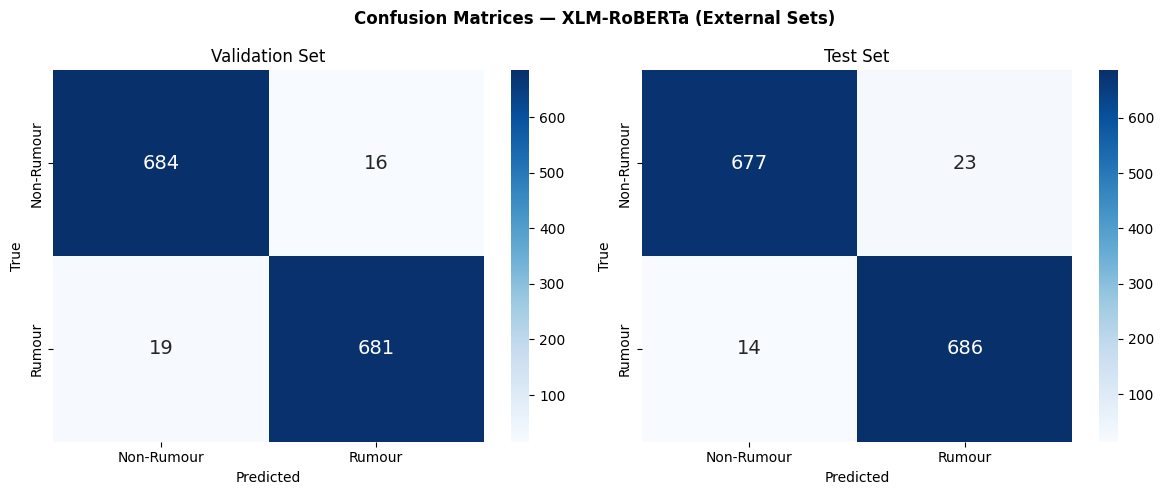

In [14]:
# ── CELL 12: Confusion Matrices ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Confusion Matrices — XLM-RoBERTa (External Sets)', fontweight='bold')
for ax, (yt, yp, title) in zip(axes, [
    (val_labels,  val_preds,  'Validation Set'),
    (test_labels, test_preds, 'Test Set')
]):
    sns.heatmap(confusion_matrix(yt, yp), annot=True, fmt='d', ax=ax,
                xticklabels=['Non-Rumour','Rumour'],
                yticklabels=['Non-Rumour','Rumour'],
                cmap='Blues', annot_kws={'size': 14})
    ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig('xlmr_confusion_matrices.png', dpi=150)
plt.show()

In [15]:
# ── CELL 13: Error Analysis ──────────────────────────────────────
df_result = df_test.copy().reset_index(drop=True)
df_result['pred']        = test_preds
df_result['prob_rumour'] = test_probs

fp = df_result[(df_result['label']==0) & (df_result['pred']==1)]
fn = df_result[(df_result['label']==1) & (df_result['pred']==0)]

print(f'False Positives (Non-Rumour → predicted Rumour): {len(fp)}')
print(f'False Negatives (Rumour → predicted Non-Rumour): {len(fn)}')

if len(fp):
    print('\nTop 5 FP (highest confidence wrong):')
    for _, row in fp.nlargest(5, 'prob_rumour').iterrows():
        print(f'  [{row["prob_rumour"]:.3f}] {str(row["text"])[:90]}')

if len(fn):
    print('\nTop 5 FN (lowest confidence wrong):')
    for _, row in fn.nsmallest(5, 'prob_rumour').iterrows():
        print(f'  [{row["prob_rumour"]:.3f}] {str(row["text"])[:90]}')

df_result.to_excel('xlmr_test_predictions.xlsx', index=False)
print('\nPredictions saved: xlmr_test_predictions.xlsx')

False Positives (Non-Rumour → predicted Rumour): 23
False Negatives (Rumour → predicted Non-Rumour): 14

Top 5 FP (highest confidence wrong):
  [1.000] মারা যাননি হান্নান মাসউদের ভাই, ছড়ানো খবরটি গুজব
  [0.999] ‘ওষুধবিহীন স্বাস্থ্যকর’ জীবনযাপনে ডা. মুজিবুর রহমানের ‘৮টি গোপন সূত্র’
  [0.999] তুই কেনে এলি সরোবরে বেহুলা সুন্দরী' এই রহস্যময় ক্যাপশনে জয়া আহসানের মোহময়ী ছবি!
  [0.999] তবে কি মৃত্যুর গুজবই সত্য!
  [0.999] সংসদীয় গণতন্ত্রে সরকার ও বিরোধী দল দ্বিচক্র যানের মতো, একটি চাকা বিকল হলে পুরো যানটি অচল 

Top 5 FN (lowest confidence wrong):
  [0.012] মার্চে ৪৭২ ভুল তথ্য শনাক্ত
  [0.014] পোস্টাল ভোট বিডিতে প্রবাসী নিবন্ধন ৭ লক্ষ পেরিয়েছে, ৫৫ লক্ষ নয়
  [0.015] রিউমর স্ক্যানারের ৬ বছর: অপতথ্যের বিবর্তনে নিরন্তর লড়াই
  [0.016] সংসদ নির্বাচন-গণভোট: লাইভ আপডেট ১০ ফেব্রুয়ারি
  [0.022] সরকারি উদ্যোগে ‘ফ্যামিলি কার্ড’, সুযোগ নিচ্ছে প্রতারকরা

Predictions saved: xlmr_test_predictions.xlsx


## Viva Cheatsheet — XLM-RoBERTa

**Q: Why XLM-RoBERTa and not mBERT or MuRIL?**
A: XLM-RoBERTa is pretrained on 2.5TB of filtered CommonCrawl data across 100 languages using the RoBERTa training objective — no next-sentence prediction, larger batches, more data. It consistently outperforms mBERT across cross-lingual benchmarks. For Bangla, XLM-R has substantially more pretraining data than mBERT and is the de facto standard multilingual baseline in recent NLP papers. Including it alongside BanglaBERT and MuRIL gives a complete picture: monolingual (BanglaBERT) vs Indic-focused (MuRIL) vs general multilingual (XLM-RoBERTa).

**Q: Why the same architecture as BanglaBERT and MuRIL?**
A: Keeping the architecture identical (encoder + [CLS] → Dropout(0.3) → Linear(768→2)) isolates the pretraining corpus as the only variable across all three BERT-based models. Any performance differences are attributable solely to pretraining — not architectural choices.

**Q: Why MAX_LEN=128?**
A: Bangla rumour headlines are short — average 9–10 words. 128 tokens captures the full headline with room to spare. Increasing to 512 would quadratically increase attention computation with no benefit on headline-length inputs.

**Q: Why class-weighted loss AND weighted sampler together?**
A: The sampler corrects batch-level class frequency so the model sees balanced batches during training. The weighted loss scales the gradient contribution of each class, penalising minority class errors more heavily. Together they prevent the model from collapsing to the majority class.

**Q: Why save the best checkpoint by Val Macro-F1 and not Val loss?**
A: Val loss can decrease while Macro-F1 stays flat if the model becomes more confident about easy examples. Macro-F1 directly measures the metric we care about and weights both classes equally, making it the correct selection criterion for a balanced binary classification task.
